<a href="https://colab.research.google.com/github/bru401/Main/blob/main/Machine_Learning/MVP_PUC-Rio/MVP_Machine_Learning_(Bruno_Reis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Bruno Renaux Mendes Reis  
**Matrícula:** 4052025001668  
**Data:** _5/7/2026_  
**Dataset:** _[Student Habits vs Academic Performance](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance)_  
**Tipo de problema:** _Regressão_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | X |
| Dataset descrito, com fonte, atributos e restrições | X |
| Dataset carregado por URL pública ou fonte diretamente acessível | X |
| Análise exploratória objetiva, conectada à modelagem | X |
| Divisão adequada em treino/teste e, se aplicável, validação | X |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | / |
| Pipeline ou sequência reprodutível de pré-processamento | / |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema (WIP)

Ao contrário do que alguns pensam, a performance acadêmica de um indivíduo não é função de apenas inteligência ou talento inato, mas de *uma série de fatores comportamentais e circunstanciais* - mas quais que seriam os mais consequentes? E poderíamos realizar previsões de performance acadêmica com base nestes? Ou será que de fato cada estudante é uma caixa-preta?

Estas perguntas são extremamente relevantes tanto para estudantes preocupados com suas notas quanto para professores interessados em compreender o perfil de seus alunos. Ademais, pode ser de importância até para orgãos públicos, interessados em medidas que aumentam a performance acadêmica média ao menor custo para os pagadores de impostos.

Sendo assim, aqui pratico, utilizando dados sintéticos, a montagem de um modelo de **regressão** que busca oferecer uma previsão de *nota de prova final* dados os valores das variáveis independentes de um aluno e no final ranquear as features mais importantes.



---



Descreva, em linguagem simples, o problema que será resolvido.

**O que incluir:**
- Qual é o contexto do problema?
- Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?
- Quem seria o usuário ou interessado nessa solução?
- Por que esse problema é relevante?

> **Comentário:** evite começar diretamente pelo código. O leitor precisa entender o problema antes de ver os dados e os modelos.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a nota de prova final de estudantes de um curso a partir de uma seleção de variáveis referentes aos comportamentos e às circunstâncias dos estudantes, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

## 1.3 Tipo de problema

**Regressão**  - prever um valor numérico contínuo.  

**Justificativa:** _A variável alvo do projeto, `exam_score`, que buscamos prever, é uma variável numérica referente à nota da prova final, variando de zero a cem._

## 1.4 Premissas, hipóteses e critérios de sucesso (WIP)

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1. Ao menos uma das variáveis preditoras do dataset explica a variável alvo significativamente_
2. _Hipótese 2. Há variáveis comportamentais, isto é, sob controle dos estudantes, que afetam a nota final_
3. _Hipótese 3. As variáveis de maior peso ainda são aquelas além do controle dos estudantes, como a idade ou a educação dos pais._

**Critérios de sucesso:**
- Métrica principal: RMSE, R² e MAE
- Resultado mínimo esperado: O R² superar 80%

# 2. Ambiente, bibliotecas e reprodutibilidade

Importações, configuração de seed e informações básicas do ambiente.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings
warnings.filterwarnings("ignore") # Configuração para não exibir os warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais (WIP)

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [ ]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados (WIP)

## 3.1 Fonte dos dados

Para o MVP, escolhi o dataset [Student Habits vs Academic Performance](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance) encontrado no site Kaggle e armazenado no [meu repositório do GitHub](https://github.com/bru401/Main/tree/main/Machine_Learning/MVP_PUC-Rio), ao lado deste notebook.

É um dataset sintético com 1.000 registros que simulam variáveis das vidas de estudantes e as notas finais que receberam. Incluindo 14 features presumidamente relevantes à previsão da variável alvo, de horas de estudo de um estudante à qualidade de sua dieta, este dataset foi montado com o expresso propósito educacional de providenciar experiência prática em análise de dados e machine learning a estudantes destas disciplinas.

## 3.2 Carga dos dados

O dataset pode ser encontrado online no Kaggle -> https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

Porém, preferi baixar o arquivo .csv e arquivá-lo em meu próprio repositório GitHub -> https://github.com/bru401/Main/tree/main/Machine_Learning/MVP_PUC-Rio

In [ ]:
# === Carga dos dados ===
df = pd.read_csv("https://github.com/bru401/Main/raw/refs/heads/main/Machine_Learning/MVP_PUC-Rio/student_habits_performance.csv", sep=',', encoding = 'ISO-8859-1')

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3.3 Visão geral do dataset

In [ ]:
# Quantidade de linhas e colunas;
# Tipos dos atributos
print("Formato do dataset:", df.shape)
print("\nVariável alvo: exam_score")
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (1000, 16)

Variável alvo: exam_score

Tipos de dados:


,tipo
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


In [ ]:
# Valores ausentes
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [ ]:
# Duplicatas
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


Antes de prosseguir, excluíremos a coluna student_id. Tal coluna é única para cada um dos alunos, portanto não nos ajudará a identificar padrões relacionados à variável alvo.

In [ ]:
# Remoção de uma coluna de ID
df = df.drop('student_id', axis=1)

## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| student_id | texto | _identificação do estudante_ | não | _Sendo única a cada estudante, não revela nada sobre a nota final_ |
| age | numérica | _idade_ | sim | _-_ |
| gender | categórica | _gênero_ | sim | _feminino, masculino e outro_ |
| study_hours_per_day | numérica | _horas de estudo por dia_ | sim | _-_ |
| social_media_hours | numérica | _uso diário de redes sociais_ | sim | _-_ |
| netflix_hours | numérica | _média diária do tempo no Netflix_ | sim | _-_ |
| part_time_job | categórica | _emprego de meio período_ | sim | _sim ou não_ |
| attendance_percentage | numérica | _comparecimento às aulas_ | sim | _0 - 100%_ |
| sleep_hours | numérica | _horas de sono_ | sim | _-_ |
| diet_quality | categórica| _qualidade da dieta_ | sim | _good (boa), fair (decente) e poor (ruim)_ |
| exercise_frequency | numérica | _frequência semanal de atividades físicas_ | sim | _-_ |
| parental_education_level | categórica | _nível educacional dos pais_ | sim | _master (mestrado), bachelor (graduação), high school (ensino médio) e none (nenhuma)_ |
| internet_quality | categórica | _conexão de internet_ | sim | _good (boa), average (mediana) e poor (fraca)_ |
| mental_health_rating | numérica | _score de saúde mental_ | sim | _1 - 10_ |
| extracurricular_participation | categórica | _atividades extracurriculares_ | sim | _sim ou não_ |
| exam_score | alvo | _Nota da prova final_ | alvo | _0 a 100_ |


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


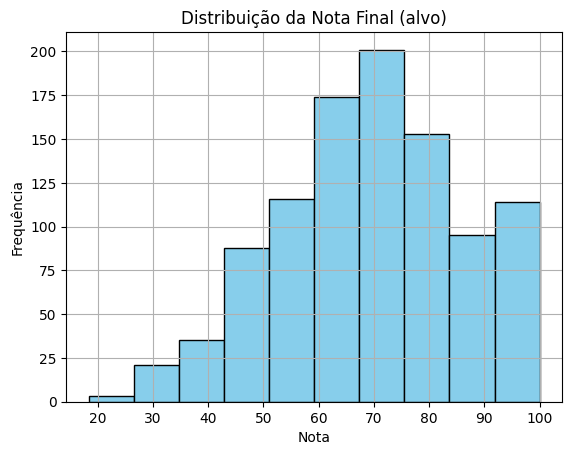

In [ ]:
df['exam_score'].hist(bins=10, edgecolor='black', color='skyblue')

# Personalização essencial
plt.title('Distribuição da Nota Final (alvo)')
plt.xlabel('Nota')
plt.ylabel('Frequência')

# Exibir o gráfico
plt.show()

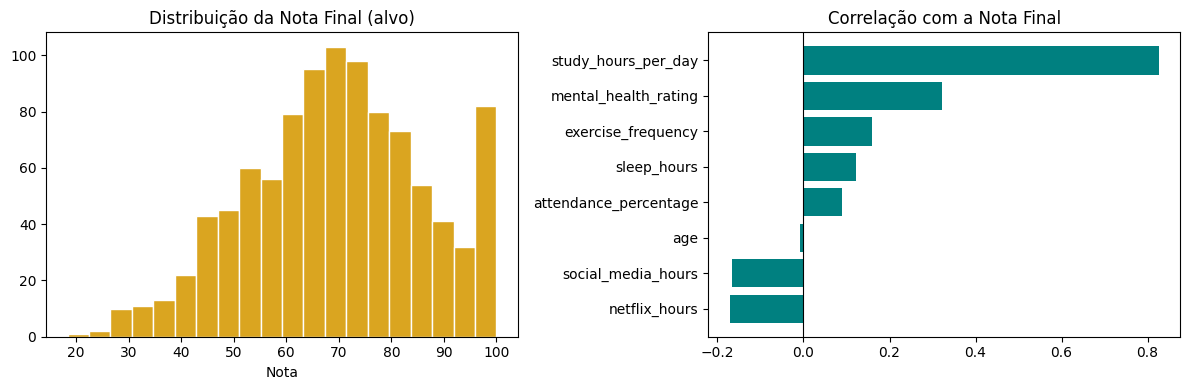

In [ ]:
# Distribuição do target exam_score (nota da prova final)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['exam_score'], bins=20, color='goldenrod', edgecolor='white')
axes[0].set_title("Distribuição da Nota Final (alvo)")
axes[0].set_xlabel("Nota")

# Correlação das numéricas com o target exam_score
# Identificação preliminar das melhores features
num_cols_preview = df.select_dtypes(include=np.number).columns.tolist()
corr_with_target = df[num_cols_preview].corr()['exam_score'].drop('exam_score').sort_values()
axes[1].barh(corr_with_target.index, corr_with_target.values, color='teal')
axes[1].set_title("Correlação com a Nota Final")
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Um gráfico de correlação irá apenas sugerir quais as features mais relevantes à target. Não assume causalidade, porém.

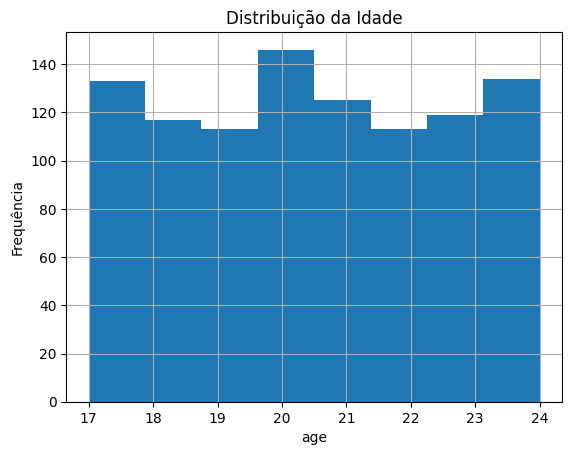

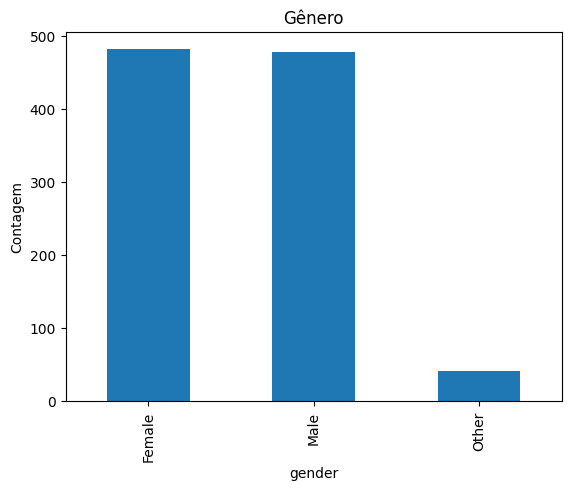

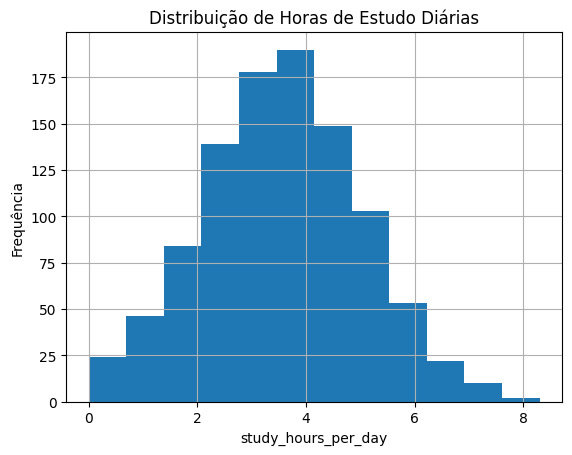

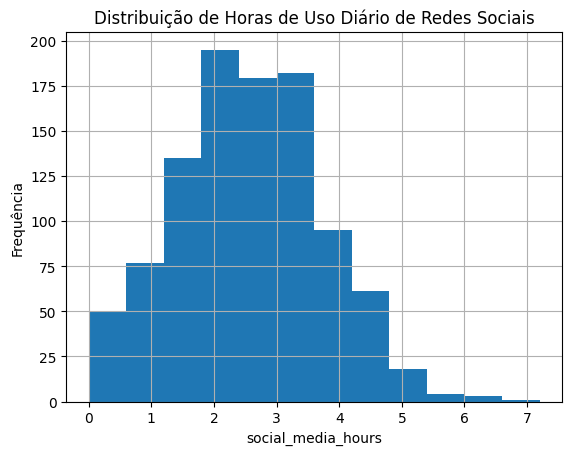

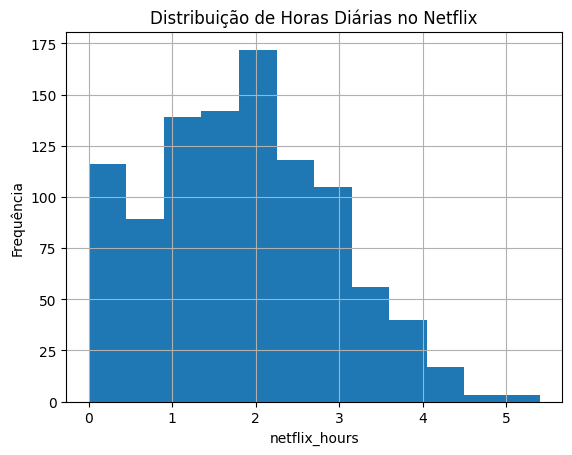

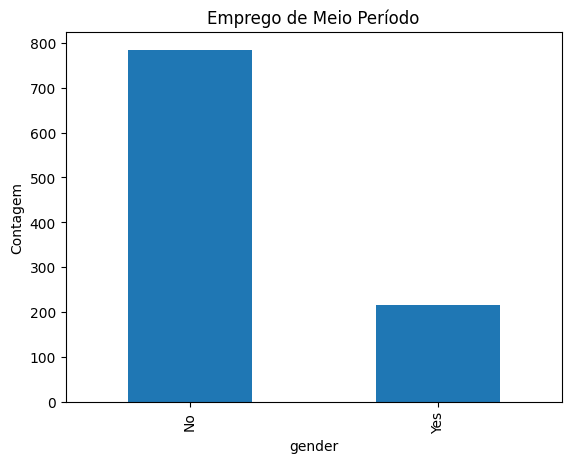

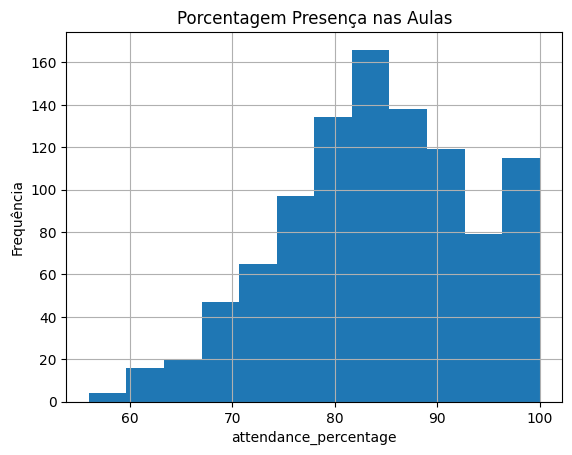

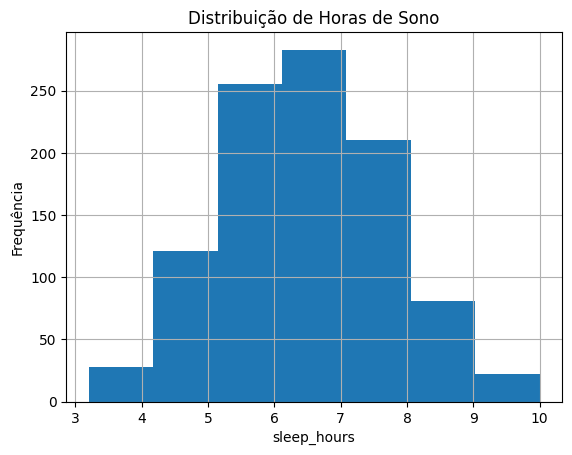

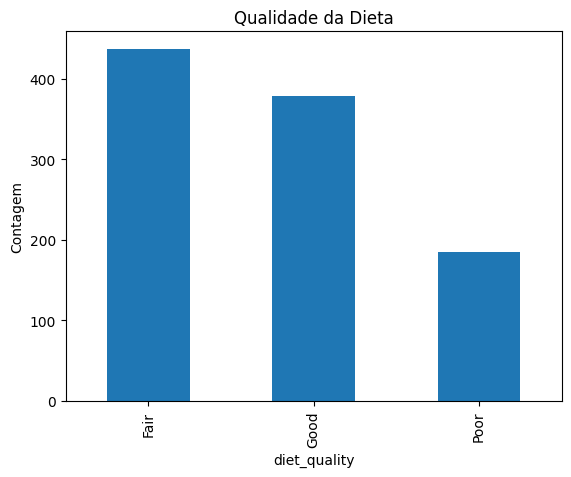

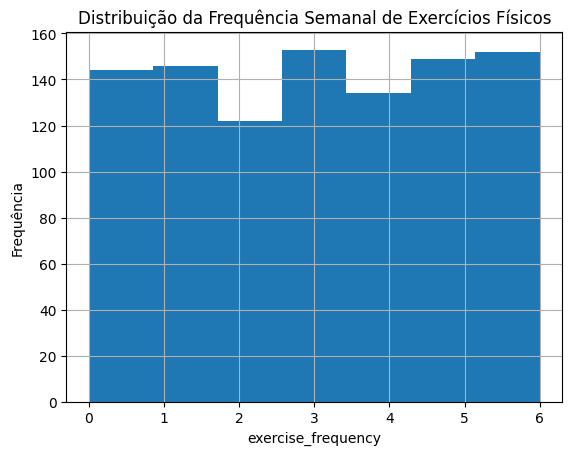

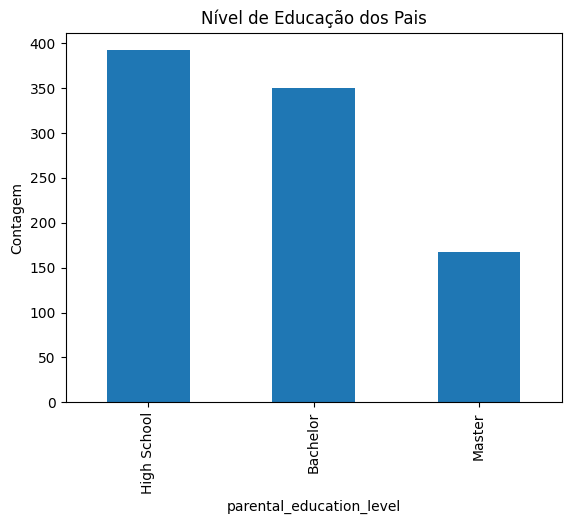

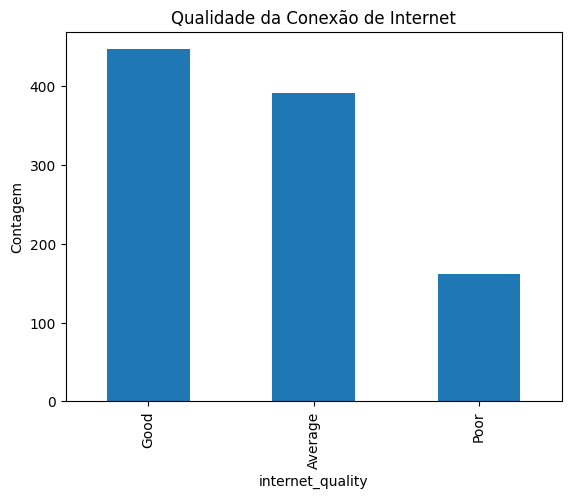

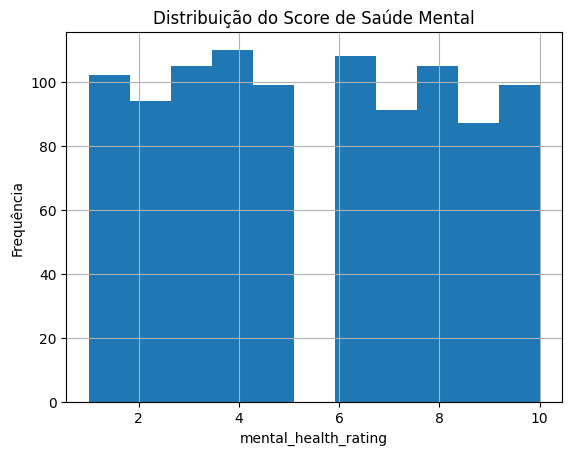

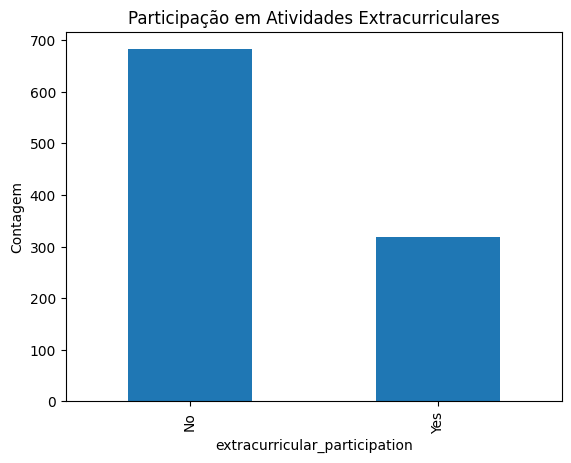

In [ ]:
df['age'].hist(bins=8)
plt.title(f"Distribuição da Idade")
plt.xlabel('age')
plt.ylabel("Frequência")
plt.show()

df['gender'].value_counts().plot(kind="bar")
plt.title(f"Gênero")
plt.xlabel('gender')
plt.ylabel("Contagem")
plt.show()

df['study_hours_per_day'].hist(bins=12)
plt.title(f"Distribuição de Horas de Estudo Diárias")
plt.xlabel('study_hours_per_day')
plt.ylabel("Frequência")
plt.show()

df['social_media_hours'].hist(bins=12)
plt.title(f"Distribuição de Horas de Uso Diário de Redes Sociais")
plt.xlabel('social_media_hours')
plt.ylabel("Frequência")
plt.show()

df['netflix_hours'].hist(bins=12)
plt.title(f"Distribuição de Horas Diárias no Netflix")
plt.xlabel('netflix_hours')
plt.ylabel("Frequência")
plt.show()

df['part_time_job'].value_counts().plot(kind="bar")
plt.title(f"Emprego de Meio Período")
plt.xlabel('gender')
plt.ylabel("Contagem")
plt.show()

df['attendance_percentage'].hist(bins=12)
plt.title(f"Porcentagem Presença nas Aulas")
plt.xlabel('attendance_percentage')
plt.ylabel("Frequência")
plt.show()

df['sleep_hours'].hist(bins=7)
plt.title(f"Distribuição de Horas de Sono")
plt.xlabel('sleep_hours')
plt.ylabel("Frequência")
plt.show()

df['diet_quality'].value_counts().plot(kind="bar")
plt.title(f"Qualidade da Dieta")
plt.xlabel('diet_quality')
plt.ylabel("Contagem")
plt.show()

df['exercise_frequency'].hist(bins=7)
plt.title(f"Distribuição da Frequência Semanal de Exercícios Físicos")
plt.xlabel('exercise_frequency')
plt.ylabel("Frequência")
plt.show()

df['parental_education_level'].value_counts().plot(kind="bar")
plt.title(f"Nível de Educação dos Pais")
plt.xlabel('parental_education_level')
plt.ylabel("Contagem")
plt.show()

df['internet_quality'].value_counts().plot(kind="bar")
plt.title(f"Qualidade da Conexão de Internet")
plt.xlabel('internet_quality')
plt.ylabel("Contagem")
plt.show()

df['mental_health_rating'].hist(bins=11)
plt.title(f"Distribuição do Score de Saúde Mental")
plt.xlabel('mental_health_rating')
plt.ylabel("Frequência")
plt.show()

df['extracurricular_participation'].value_counts().plot(kind="bar")
plt.title(f"Participação em Atividades Extracurriculares")
plt.xlabel('extracurricular_participation')
plt.ylabel("Contagem")
plt.show()

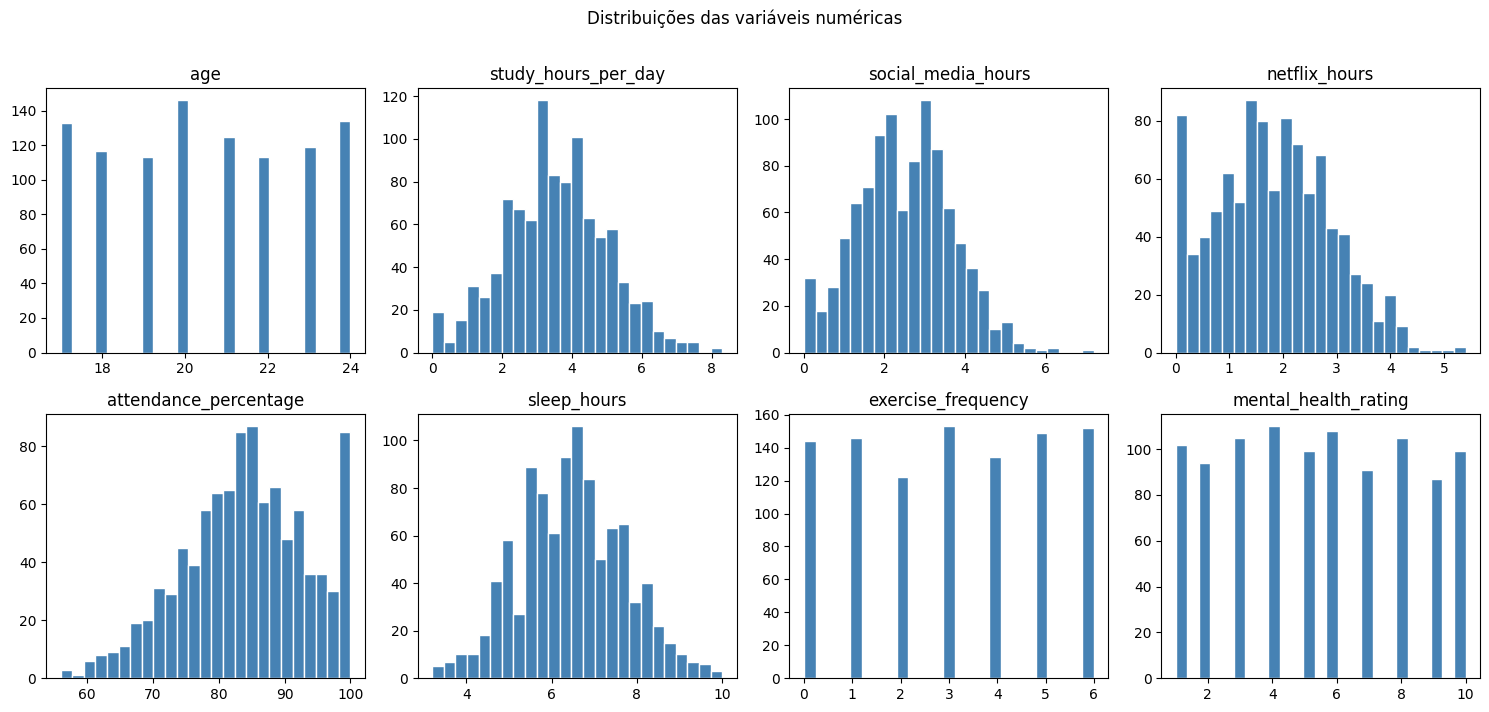

In [ ]:
# === Distribuições das variáveis numéricas ===
num_cols_eda = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle("Distribuições das variáveis numéricas", y=1.01)
plt.tight_layout()
plt.show()


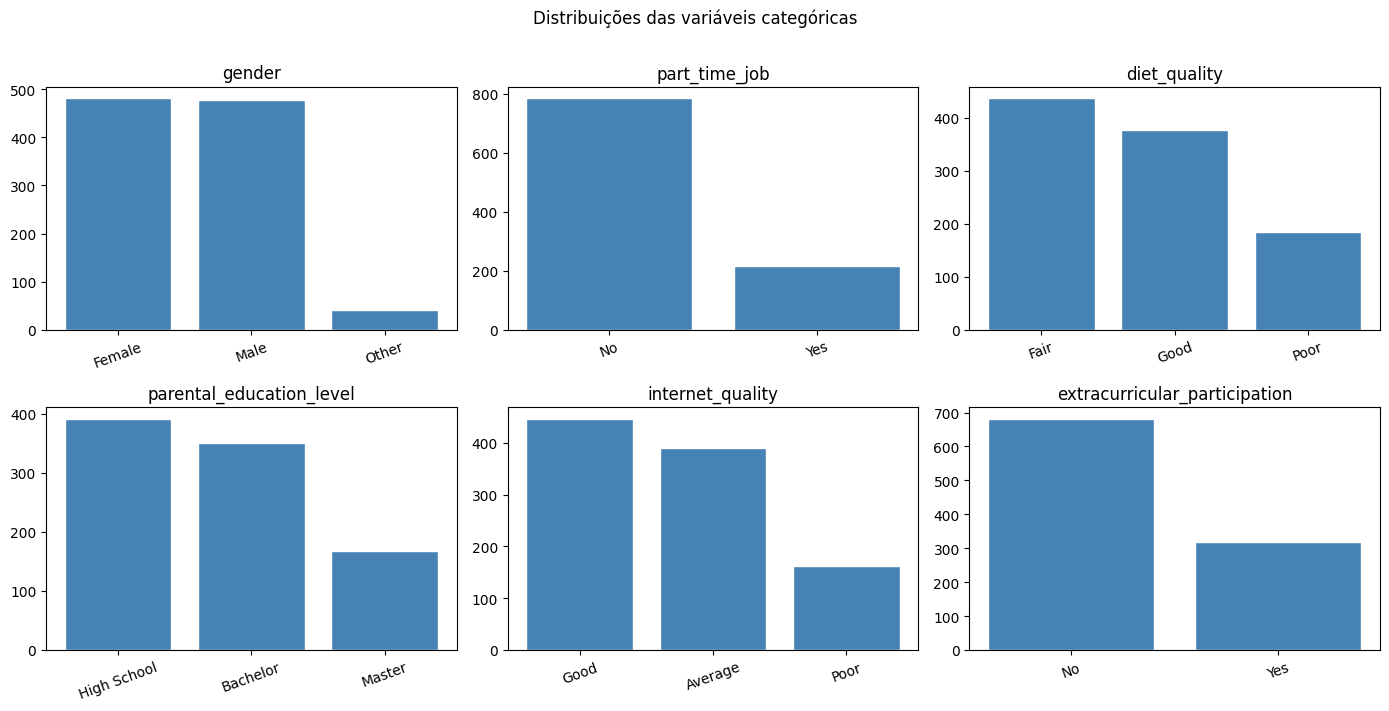

In [ ]:
# === Distribuições das variáveis categóricas ===
cat_cols_eda = ['gender', 'part_time_job', 'diet_quality',
                'parental_education_level', 'internet_quality', 'extracurricular_participation']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle("Distribuições das variáveis categóricas", y=1.01)
plt.tight_layout()
plt.show()


## 4.1 Síntese da análise exploratória

**Principais achados da
EDA**
- As **variáveis preditoras** se encontram num misto de distribuições normais (Ex: horas de sono) e distribuições uniformes (Ex: score de saúde mental)
- A **variável alvo**, `exam_score`, tem distribuição normal, apenas com uma notável excessão na nota máxima, 100, cuja frequência se equipara à da mediana. Além disso possuí leve assimetria negativa, isto é, à esquerda.
- Entre as variáveis númericas, não há amplitude significante de escala, com a maior parte dos valores não passando de dois dígitos.  

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> _Preencha aqui._


# 5. Preparação dos dados e Pré-processamento

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [ ]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "exam_score"                  # para clusterização, use None
PROBLEM_TYPE = "regressao"    # "classificacao", "regressao", "clusterizacao" ou "serie_temporal"
ID_COLUMNS = []                    # ex.: ["id_cliente"]
DATE_COLUMN = None                 # ex.: "data"; necessário para séries temporais
DROP_COLUMNS = []                  # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: churn
Número de features: 5
Features: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses', 'canal_aquisicao', 'usa_app']


In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (400, 5) | Teste: (100, 5)


### 5.1 Encoding

Para utilizarmos as X variáveis categóricas no modelo de regressão, precisamos torná-las variáveis numéricas.
No entanto, temos múltiplas variáveis categóricas que possuem clara ordenação:

Ex: (Dieta) Poor < Fair < Good

<br>

Sendo assim, para preservar o significado destas categorias, é preciso refleti-lo nos números.

Poor (Ruim) = 0

Fair (Decente) = 1

Good (Boa) = 2

In [ ]:
diet_quality = {'Poor': 0, 'Fair': 1, 'Good': 2}
parental_education_level = {'High School' : 0, 'Bachelor' : 1, 'Master' : 2}
internet_quality  = {'Poor' : 0, 'Average' : 1, 'Good' : 2}

In [ ]:
df['dq_e'] = df['diet_quality'].map(diet_quality)
df['pel_e'] = df['parental_education_level'].map(parental_education_level)
df['iq_e'] = df['internet_quality'].map(internet_quality)

df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,dq_e,pel_e,iq_e
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,1,2.0,1
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2,0.0,1
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,0,0.0,0
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,0,2.0,2
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,1,2.0,2


As outras variáveis categóricas não possuem uma ordenação "correta".
Neste caso, utilizamos one hot encoding para criarmos novas colunas apenas com valores 0 ou 1, correspondendo à negação ou afirmação de uma dada característica.

Ex: Se um estudante não tem emprego de meio período o valor desta coluna será 0.

In [ ]:
# Criando as novas colunas
categorical_features = ['gender', 'part_time_job', 'extracurricular_participation']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[categorical_features])

In [ ]:
# Incorporando-as ao dataset
df = pd.concat([df,ohetransform], axis=1)

In [ ]:
# Montagem do dataframe pronto para treinamento
# Aqui removemos as colunas originais já substituídas pelos encodings.
df2 = df.drop([
    'gender', 'part_time_job',
    'diet_quality', 'parental_education_level', 'internet_quality',
    'extracurricular_participation'
], axis=1)

In [ ]:
# Movendo o target exam_score para a última coluna
df2['exam_score'] = df2.pop('exam_score')

In [ ]:
df2.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,dq_e,pel_e,iq_e,gender_Female,gender_Male,gender_Other,part_time_job_No,part_time_job_Yes,extracurricular_participation_No,extracurricular_participation_Yes,exam_score
0,23,0.0,1.2,1.1,85.0,8.0,6,8,1,2.0,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,56.2
1,20,6.9,2.8,2.3,97.3,4.6,6,8,2,0.0,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,100.0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,0,0.0,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,34.3
3,23,1.0,3.9,1.0,71.0,9.2,4,1,0,2.0,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,26.8
4,19,5.0,4.4,0.5,90.9,4.9,3,1,1,2.0,2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,66.4


### 5.2 Limpeza dos Dados

Não encontramos duplicatas na seção 3, mas verificamos que há valores ausentes na coluna da educação dos pais (agora representada pela coluna pel_e, numérica).

Ao invés de simplesmente removermos as linhas com NA, preencheremos pel_e (parental_education_level) com a moda:

In [ ]:
moda_pel = df2['pel_e'].mode()[0]
df2['pel_e'] = df2['pel_e'].fillna(moda_pel)

## 5.3 Decisões de pré-processamento (WIP)

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> _Preencha aqui._


| Decisão | Justificativa |
|---|---|
| **Imputação com mediana** para numéricas | Mediana é mais robusta que média para distribuições assimétricas |
| **Imputação com moda** para categóricas | `parental_education_level` tem NaN; preencher com o valor mais frequente preserva as linhas |
| **OrdinalEncoder** para `diet_quality`, `internet_quality`, `parental_education_level` | Essas variáveis têm ordem real (Poor < Fair < Good). OHE ignoraria essa ordem e criaria colunas desnecessárias |
| **OneHotEncoder com `drop='first'`** para nominais | `gender`, `part_time_job` e `extracurricular_participation` não têm ordem. `drop='first'` evita multicolinearidade |
| **StandardScaler** em todas as numéricas | Ridge e Lasso penalizam coeficientes — features em escalas diferentes seriam penalizadas de forma desigual |
| **Split antes do fit** | Scaler e encoders são ajustados apenas no treino, evitando data leakage |

**Resposta:**  
> _Preencha aqui._

# 6. Pipeline

Crie uma sequência reprodutível de tratamento dos dados

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


## 6.1 Justificativa da divisão (WIP)

- **Holdout 80/20:** com 1.000 linhas, a proporção é adequada — 800 para treino e 200 para teste. Validação cruzada será usada na otimização de hiperparâmetros, não na avaliação final.
- **Sem estratificação:** `exam_score` é contínuo. A aleatorização com seed fixa garante distribuições semelhantes entre treino e teste.
- **Split antes do pré-processamento:** o `StandardScaler` e os encoders são ajustados (`fit`) apenas no treino e aplicados (`transform`) no teste — prevenindo data leakage.
- **Sem divisão temporal:** o dataset é um snapshot, não uma série temporal. Não há critério temporal para o corte.


In [ ]:
# 1) Separação do target e variáveis preditoras
array = df2.values
X = array[:,0:18] # atributos
y = array[:,18] # classe (target)

In [ ]:
# 2) Holdout
# Para que o scaler não aprenda os dados de teste que o modelo não deveria conhecer, a primeira coisa que fazemos é o split dos dados.
# WIP Mudar nomes?

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7) # faz a divisão

In [ ]:
# 2.5) Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7) # faz o particionamento em 10 folds

In [ ]:
# 3) Scaler - o modelo aprende só com os dados de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform no treino
X_test_scaled  = scaler.transform(X_test)        # só transform no teste

feature_cols = [c for c in df2.columns if c != 'exam_score']
print("Treino:", X_train_scaled.shape, "| Teste:", X_test_scaled.shape)
print("Features usadas:", feature_cols)

Treino: (800, 18) | Teste: (200, 18)
Features usadas: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'dq_e', 'pel_e', 'iq_e', 'gender_Female', 'gender_Male', 'gender_Other', 'part_time_job_No', 'part_time_job_Yes', 'extracurricular_participation_No', 'extracurricular_participation_Yes']


In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses']
Colunas categóricas: ['canal_aquisicao', 'usa_app']


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


Modelo        RMSE    DP        R2
LR           5.36    4.28     0.899
Ridge        5.36    4.27     0.899
Lasso        5.96    4.29     0.875
KNN         11.85   15.44     0.507
CART         9.93   13.40     0.662
SVM         10.09   11.14     0.643


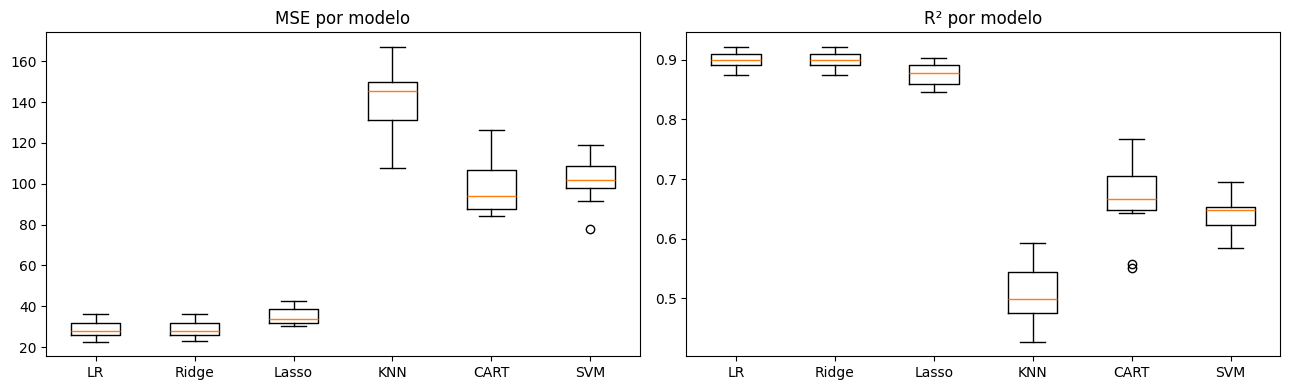

In [ ]:
# Definindo uma seed global para esta célula de código
np.random.seed(7)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results_mse = []
results_r2  = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('LR', LinearRegression()))
models.append(('Ridge', Ridge()))
models.append(('Lasso', Lasso()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVM', SVR()))

print("Modelo        RMSE    DP        R2")

# Avaliando um modelo por vez
for name, model in models:
    cv_mse = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='neg_mean_squared_error')
    cv_r2  = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='r2')
    results_mse.append(cv_mse)
    results_r2.append(cv_r2)
    names.append(name)
    rmse = np.sqrt(abs(cv_mse.mean()))
    # imprime MSE, desvio padrão do MSE e RMSE (Mean squared error e Root Mean squared error!) dos 10 resultados da validação cruzada
    print(f"{name:<8} {rmse:>8.2f}  {cv_mse.std():>6.2f}  {cv_r2.mean():>8.3f}")

# Boxplots de comparação dos modelos
# Um para mínimos quadrados e um para o R2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot([-r for r in results_mse])
axes[0].set_xticklabels(names)
axes[0].set_title("MSE por modelo")
axes[1].boxplot(results_r2)
axes[1].set_xticklabels(names)
axes[1].set_title("R² por modelo")
plt.tight_layout()
plt.show()

Obs: Quanto *menor* o MSE (mínimos quadrados), melhor; quanto *maior* o R2, melhor

## 7.1 Justificativa dos modelos (WIP)

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> _Preencha aqui._


| Modelo | Justificativa |
|---|---|
| **DummyRegressor (mediana)** | Baseline ingênuo. Prevê a mediana para todos — se um modelo treinado não supera isso, não aprendeu nada. Mediana é preferível à média pois é mais robusta. |
| **LinearRegression** | Referência linear pura, sem regularização. Serve para medir o ganho que Ridge e Lasso trazem. |
| **Ridge** | Regressão linear com regularização L2. Robusto a multicolinearidade (ex.: `social_media_hours` e `netflix_hours`). Coeficientes interpretáveis. |
| **Lasso** | Regularização L1 — zera coeficientes de features irrelevantes, realizando seleção automática. Útil para confirmar quais variáveis realmente contribuem. |
| **KNN** | Não-paramétrico, captura vizinhanças locais. Serve de referência para verificar se o problema tem estrutura não-linear simples. |
| **DecisionTree** | Captura não-linearidades e interações. Tende ao overfitting sem poda — útil como diagnóstico. |
| **RandomForest** | Conjunto de árvores, mais robusto que uma única. Serve como referência de teto: se superar Ridge/Lasso em muito, há não-linearidades relevantes que modelos lineares não capturam. |

**Obs:** Ridge e Lasso são os modelos preferíveis, por serem lineares, interpretáveis e adequados ao objetivo de entender quais fatores mais influenciam a nota.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.60,0.450000,0.500000,0.077
LogisticRegression,0.74,0.738798,0.798333,0.078
RandomForest,0.65,0.650690,0.682500,0.844


In [ ]:
# WIP
print(f"{'Modelo':<16} {'RMSE':>8}  {'R²':>8}  {'MAE':>8}")
print("-" * 46)

all_models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge',            Ridge()),
    ('Lasso',            Lasso()),
    ('KNN',              KNeighborsRegressor()),
    ('DecisionTree',     DecisionTreeRegressor()),
    ('SVR',              SVR()),
    ('RandomForest',     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=7)),
]

best = {"nome": "", "r2": -999}

for name, model in all_models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<16} {rmse:>8.2f}  {r2:>8.3f}  {mae:>8.2f}")
    if r2 > best["r2"]:
        best = {"nome": name, "r2": r2, "rmse": rmse, "mae": mae}

print(f"\n✅ Melhor modelo: {best['nome']}  (R²={best['r2']:.3f}, RMSE={best['rmse']:.2f})")

Modelo               RMSE        R²       MAE
----------------------------------------------
LinearRegression     5.50     0.884      4.41
Ridge                5.50     0.884      4.41
Lasso                5.91     0.867      4.60
KNN                 11.14     0.526      8.81
DecisionTree         9.72     0.639      7.54
SVR                  9.04     0.688      6.95
RandomForest         7.34     0.794      5.83

✅ Melhor modelo: LinearRegression  (R²=0.884, RMSE=5.50)


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> _Preencha aqui._


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.7512739088255881
Melhores hiperparâmetros: {'model__max_depth': 5, 'model__min_samples_split': 9, 'model__n_estimators': 201}


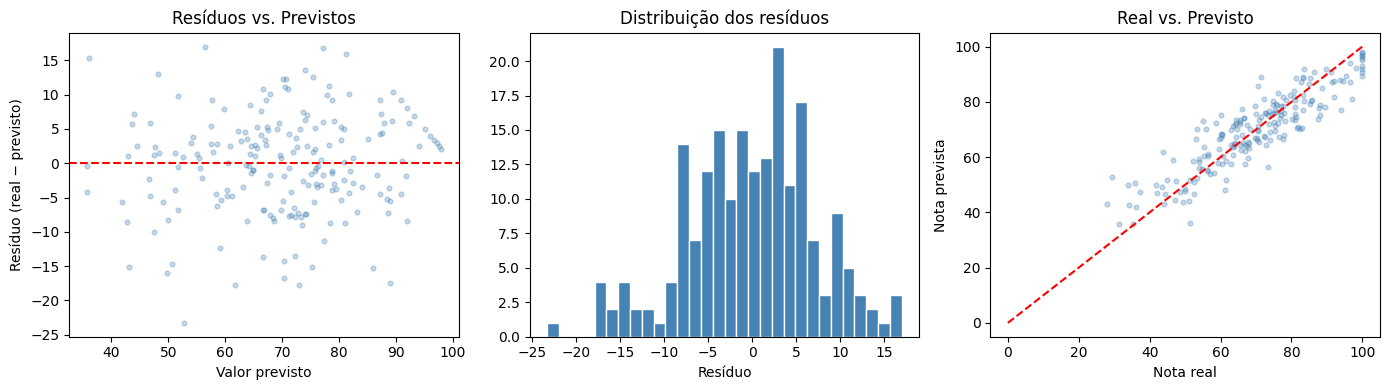

Resíduo médio: -0.1745  (ideal: próximo de 0)
Desvio padrão dos resíduos: 7.34


In [ ]:
# Gráfico de resíduos:
# Aleatório ou com padrão?
#WIP WIP WIP

# Retreinando o modelo Random Forest para o plot
best_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=7)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)
residuos = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred_best, residuos, alpha=0.3, s=12, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Valor previsto")
axes[0].set_ylabel("Resíduo (real − previsto)")
axes[0].set_title("Resíduos vs. Previstos")

axes[1].hist(residuos, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Resíduo")

axes[2].scatter(y_test, y_pred_best, alpha=0.3, s=12, color='steelblue')
lim = max(y_test.max(), y_pred_best.max())
axes[2].plot([0, lim], [0, lim], color='red', linestyle='--')
axes[2].set_xlabel("Nota real")
axes[2].set_ylabel("Nota prevista")
axes[2].set_title("Real vs. Previsto")

plt.tight_layout()
plt.show()

print(f"Resíduo médio: {residuos.mean():.4f}  (ideal: próximo de 0)")
print(f"Desvio padrão dos resíduos: {residuos.std():.2f}")


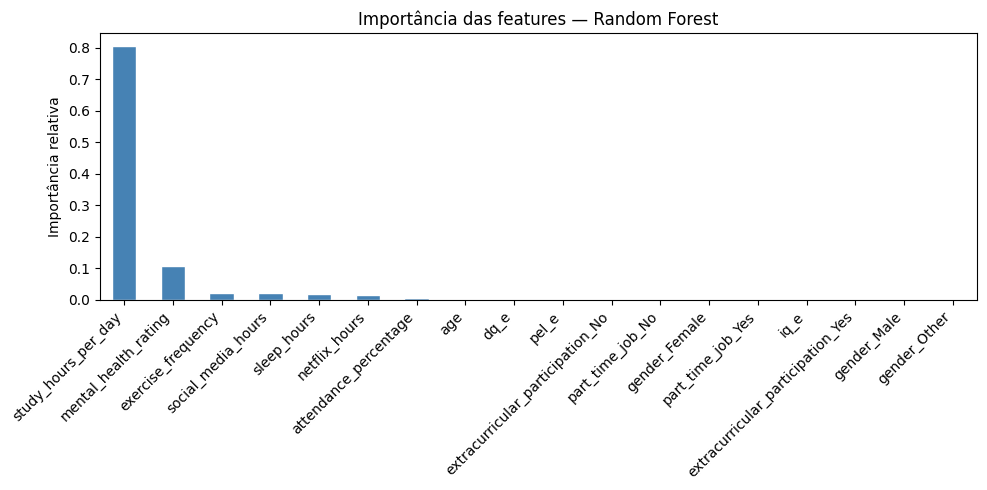

Top 5 features mais importantes:


,importância
study_hours_per_day,0.806624
mental_health_rating,0.108463
exercise_frequency,0.020964
social_media_hours,0.020223
sleep_hours,0.019350


In [ ]:
# Relevância das Features
# Mostra quais variáveis mais contribuem para a previsão da nota. Útil para entender o modelo e justificar as escolhas de features.
# WIP WIP WIP

importances = pd.Series(best_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Importância das features — Random Forest")
plt.ylabel("Importância relativa")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Se uma feature tem importância ≈ 0, ela não nos serve. Muitas vezes é melhor remove-las
print("Top 5 features mais importantes:")
display(importances.head(5).to_frame("importância"))


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.75      0.78      0.76        60
           1       0.65      0.60      0.62        40

    accuracy                           0.71       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.71      0.71      0.71       100



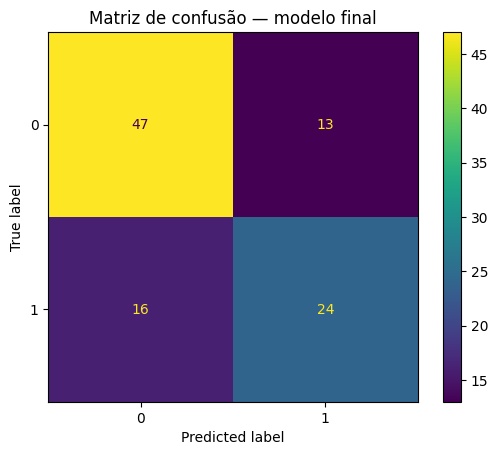

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
